### Analyze the impact of Fed Fund Rate to yield curve using Linear Regression and Error Correction Model (ECM)


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.stattools import adfuller

In [ ]:
# Load datasets
df_treasury = pd.read_csv('daily-treasury-rates.csv')
df_fed = pd.read_csv('FEDFUNDS.csv')

def prep_data(df_treasury, df_fed):
    df_treasury['Date'] = pd.to_datetime(df_treasury['Date'])
    df_treasury = df_treasury.set_index('Date')
    df_fed['observation_date'] = pd.to_datetime(df_fed['observation_date'])
    df_fed = df_fed.set_index('observation_date')
    df_fed = df_fed.rename(columns={'FEDFUNDS': 'FED'})
    df_combined = df_treasury.join(df_fed[['FED']], how='outer')
    df_combined['FED'] = df_combined['FED'].ffill()
    df_combined = df_combined.dropna(subset=['1 Mo'])
    df_combined = df_combined.dropna(subset=['FED'])
    df_combined = df_combined.sort_index(ascending=False)

    return df_combined

df_combined = prep_data(df_treasury, df_fed)

print(f"Combined rows: {len(df_combined)}")
display(df_combined.head())

Combined rows: 4160


,1 Mo,1.5 Month,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr,FED
Date,,,,,,,,,,,,,,,
2026-08-19,3.77,3.77,3.81,3.86,3.88,3.94,4.00,4.19,4.25,4.35,4.48,4.65,5.17,5.19,3.63
2026-08-18,3.78,3.78,3.82,3.86,3.88,3.94,3.99,4.19,4.26,4.37,4.53,4.71,5.28,5.28,3.63
2026-08-17,3.79,3.80,3.82,3.87,3.89,3.95,4.00,4.19,4.25,4.38,4.54,4.72,5.30,5.31,3.63
2026-08-14,3.79,3.80,3.81,3.86,3.88,3.95,3.98,4.17,4.24,4.36,4.51,4.68,5.25,5.25,3.63
2026-08-13,3.79,3.79,3.81,3.87,3.88,3.94,3.97,4.15,4.20,4.32,4.47,4.63,5.20,5.21,3.63


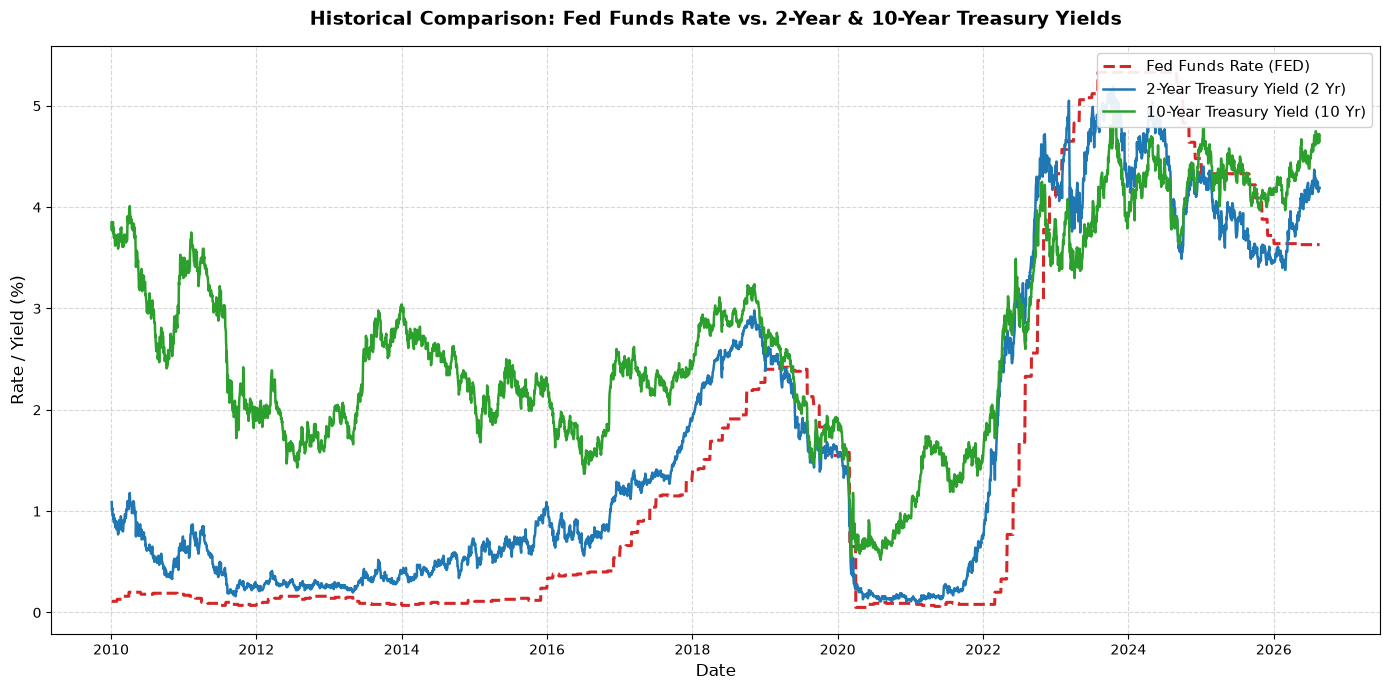

In [ ]:
df_plot = df_combined.sort_index(ascending=True)

plt.figure(figsize=(14, 7), dpi=100)

plt.plot(df_plot.index, df_plot['FED'], label='Fed Funds Rate (FED)', color='#d62728', linewidth=2.2, linestyle='--')
plt.plot(df_plot.index, df_plot['2 Yr'], label='2-Year Treasury Yield (2 Yr)', color='#1f77b4', linewidth=1.8)
plt.plot(df_plot.index, df_plot['10 Yr'], label='10-Year Treasury Yield (10 Yr)', color='#2ca02c', linewidth=1.8)

plt.title('Historical Comparison: Fed Funds Rate vs. 2-Year & 10-Year Treasury Yields', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rate / Yield (%)', fontsize=12)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Doing regression on Rate vs FFR directly would cause spurious regression, leading to high R2 but not capturing the real casual inference.
# Often, the Rate and FFR are non-stationary time series. OLS requires the series to be stationary I(0), or co-integrated.
# Note the residual assumption in OLS must be white noise: ε_t ~ i.i.d. (0, σ²) with zero autocorrelation and homoskedasticity.

# Performed ADF test to verify whether time series is stationary; H0: non-stationary
# Taking Diff(1) usually remove historical memory and left "the change" as stationary
# If combination of non-stationary time series becomes stationary, cointegration exist and must perform Error Correction Model (ECM)
# ECM is required to capture both long-term equilibrium and short-term adjustment speed.
# The table shows that Diff(1) are stationary series.

series_to_test = ['FED', '1 Mo', '3 Mo', '6 Mo', '1 Yr', '2 Yr', '5 Yr', '10 Yr', '30 Yr']

def perform_adf_test(df, columns):
    adf_results = []
    
    for col in columns:
        s = df[col].dropna()
        
        # 1. Test in Levels (Original Series)
        res_level = adfuller(s, autolag='AIC', result_object=False)
        p_val_level = res_level[1]
        
        # 2. Test in First Differences (Delta = Today - Yesterday)
        s_diff = s.diff().dropna()
        res_diff = adfuller(s_diff, autolag='AIC', result_object=False)
        p_val_diff = res_diff[1]
        
        adf_results.append({
            'Series': col,
            'Level Stat': round(res_level[0], 4),
            'Level p-val': round(p_val_level, 4),
            'Level Stationary?': 'Yes' if p_val_level < 0.05 else 'No',
            'Diff Stat': round(res_diff[0], 4),
            'Diff p-val': round(p_val_diff, 4),
            'Diff Stationary?': 'Yes' if p_val_diff < 0.05 else 'No'
        })
        
    return pd.DataFrame(adf_results).set_index('Series')

adf_summary = perform_adf_test(df_combined, series_to_test)
display(adf_summary)


,Level Stat,Level p-val,Level Stationary?,Diff Stat,Diff p-val,Diff Stationary?
Series,,,,,,
FED,-1.4030,0.5808,No,-6.3350,0.0,Yes
1 Mo,-1.1224,0.7061,No,-10.5090,0.0,Yes
3 Mo,-1.2789,0.6388,No,-7.7687,0.0,Yes
6 Mo,-1.2715,0.6421,No,-8.3982,0.0,Yes
1 Yr,-1.4345,0.5656,No,-8.7017,0.0,Yes
2 Yr,-1.6701,0.4466,No,-9.8536,0.0,Yes
5 Yr,-1.9151,0.3250,No,-48.0926,0.0,Yes
10 Yr,-1.9757,0.2973,No,-47.8443,0.0,Yes
30 Yr,-1.9006,0.3318,No,-34.4709,0.0,Yes


In [ ]:
# HAC (Newey-West) adjusts how OLS standard errors are estimated by relaxing the i.i.d. assumption, allowing residuals to be
# 1) autocorrelated (serially dependent) and 2) heteroskedastic (non-constant variance).
# The adjustment corrects OLS standard errors being understated, which otherwise makes p-values artificially low.
# Perform OLS to see if there are laggs in yield change vs FFR change, reviewing the statistics using HAC

df_diff = df_combined.sort_index(ascending=True).diff().dropna()

max_lag = 20  # Test lags from 0 to 20 trading days (~1 month)
tenors = ['1 Mo', '3 Mo', '6 Mo', '1 Yr', '2 Yr', '5 Yr', '10 Yr', '30 Yr']

diff_results = []

for tenor in tenors:
    df_t = df_diff[[tenor, 'FED']].dropna()
    
    y = df_t[tenor]
    
    best_aic = np.inf
    best_lag = 0
    best_model_hac = None
    
    for lag in range(0, max_lag + 1):
        x_shifted = df_t['FED'].shift(lag)
        
        valid_idx = x_shifted.notna()
        y_valid = y[valid_idx]
        x_valid = x_shifted[valid_idx]
        
        X = sm.add_constant(x_valid)
        model = sm.OLS(y_valid, X).fit()
        
        if model.aic < best_aic:
            best_aic = model.aic
            best_lag = lag
            # Apply HAC (Newey-West) robust covariance correction (maxlags=5)
            best_model_hac = model.get_robustcov_results(cov_type='HAC', maxlags=5)
            
    beta = best_model_hac.params[1]
    se_hac = best_model_hac.bse[1]
    p_val_hac = best_model_hac.pvalues[1]
    r2 = best_model_hac.rsquared
    
    diff_results.append({
        'Tenor': tenor,
        'Optimal Lag (Days)': best_lag,
        'Delta Beta (Pass-Through)': round(beta, 4),
        'HAC Std Error': round(se_hac, 4),
        'HAC P-Value': round(p_val_hac, 4),
        'R-Squared': round(r2, 4),
        'AIC': round(best_aic, 2)
    })

# 2. Display Results DataFrame
results_diff_df = pd.DataFrame(diff_results).set_index('Tenor')
display(results_diff_df)


,Optimal Lag (Days),Delta Beta (Pass-Through),HAC Std Error,HAC P-Value,R-Squared,AIC
Tenor,,,,,,
1 Mo,0,0.1614,0.0969,0.0967,0.0153,-1815.12
3 Mo,0,-0.0230,0.2085,0.9121,0.0003,-1850.05
6 Mo,0,0.0236,0.0539,0.6615,0.0003,-1760.05
1 Yr,0,0.0727,0.0786,0.3555,0.0011,-1404.58
2 Yr,0,-0.1211,0.1390,0.3841,0.0016,-1166.75
5 Yr,0,-0.1405,0.1460,0.3368,0.0021,-1164.84
10 Yr,0,-0.1561,0.1119,0.1640,0.0032,-1242.84
30 Yr,0,-0.1956,0.0921,0.0344,0.0057,-1297.81


Table 1 tests stationarity. All 9 series (FED + 8 tenors) are non-stationary in levels (p > 0.05) but become stationary after first-differencing (p ≈ 0.000) — meaning any regression must use differenced data, not levels.

Table 2 regresses daily ΔYield on daily ΔFED using the now-stationary differenced series, with HAC correcting the standard errors for autocorrelation/heteroskedasticity (since daily financial residuals violate the i.i.d. assumption OLS assumes). Optimal lag is 0 for every tenor, R² is negligible (0.03%–1.5%), and HAC p-values are mostly insignificant except a borderline signal at 30Yr.

Table 1 explains why the earlier levels-based regression showed a spuriously high R² (both series just trended together over time). Table 2 is the corrected version using proper stationary data and valid standard errors — and it shows that once you fix the methodology, daily Fed Funds changes have little to no real explanatory power over daily Treasury yield changes at any tenor.

Two key economic implications: (1) Treasury markets are forward-looking — FOMC moves are priced in ahead of the announcement via data and guidance, so same-day reaction is naturally weak; and (2) frequency mismatch — Fed Funds only moves a few times a year (mostly zero on any given day) while yields move continuously, capping how much a contemporaneous daily regression can ever explain.

In [ ]:
# Short-to-mid tenors are cointegrated with the Fed Funds Rate (FFR); longer tenors are more affected by other macroeconomic factors (e.g., inflation expectations and term premia).
# Long-term Beta shows FFR has a diminishing impact on the long end; Short-term Beta reflects that Fed policy is already "priced in" and does not significantly move yields on announcement day.
# Gamma and Half-life measure the adjustment speed and time required to revert to the long-term equilibrium ("fair value"); e.g., active arbitrage between FFR and 1M T-bills (near-perfect substitutes) drives rapid convergence (~11 days).

df_ecm = df_combined.sort_index(ascending=True).dropna(subset=['FED'])
tenors = ['1 Mo', '3 Mo', '6 Mo', '1 Yr', '2 Yr', '5 Yr', '10 Yr', '30 Yr']
ecm_results = []

for tenor in tenors:
    df_t = df_ecm.dropna(subset=[tenor, 'FED']).copy()
    y = df_t[tenor]
    x = df_t['FED']
    
    # H0: no conintegration
    coint_t, pvalue, crit_value = coint(y, x)
    
    # Phase I: Y_t = Beta_long * X_t + Const + Error_t
    X_level = sm.add_constant(x)
    model_long = sm.OLS(y, X_level).fit()
    
    # Take Error Correction Term (ECT) and shift by 1
    df_t['ECT_lag1'] = model_long.resid.shift(1)
    
    # ECM Dynamics
    # Phase II: Delta_Y_t = Beta_short * Delta_X_t + Gamma * ECT_lag1 + Const
    df_t['delta_y'] = y.diff()
    df_t['delta_x'] = x.diff()
    
    df_t_clean = df_t.dropna()
    
    Y_ecm = df_t_clean['delta_y']
    X_ecm = sm.add_constant(df_t_clean[['delta_x', 'ECT_lag1']])
    
    # fit ECM
    model_ecm = sm.OLS(Y_ecm, X_ecm).fit()
    
    is_coint = "Yes" if pvalue < 0.05 else "No"
    gamma = model_ecm.params['ECT_lag1']
    
    # Calculate Half-Life (Days); Only meaningful when Gamma is negative
    if gamma < 0 and gamma > -1:
        half_life = np.log(2) / -np.log(1 + gamma)
    else:
        half_life = np.nan
        
    ecm_results.append({
        'Tenor': tenor,
        'Cointegrated? (p<0.05)': is_coint,
        'Long-Term Beta': model_long.params['FED'],
        'Short-Term Beta': model_ecm.params['delta_x'],
        'Speed of Adj (Gamma)': gamma,
        'Half-Life (Days)': half_life
    })

ecm_df = pd.DataFrame(ecm_results).set_index('Tenor')
display(ecm_df.round(4))


,Cointegrated? (p<0.05),Long-Term Beta,Short-Term Beta,Speed of Adj (Gamma),Half-Life (Days)
Tenor,,,,,
1 Mo,Yes,1.0362,0.1716,-0.0609,11.0355
3 Mo,Yes,1.0363,-0.0235,0.0005,NaN
6 Mo,No,1.0090,0.0156,0.0051,NaN
1 Yr,Yes,0.9451,0.0750,-0.0013,525.6278
2 Yr,Yes,0.8304,-0.1155,-0.0023,295.1866
5 Yr,Yes,0.6073,-0.1294,-0.0050,138.3312
10 Yr,No,0.4406,-0.1402,-0.0099,69.8638
30 Yr,No,0.3080,-0.1823,-0.0136,50.6529


Table 3 (ECM) shows that short-to-belly tenors (1Mo–5Yr) are cointegrated with FED, meaning a long-run equilibrium exists even though daily changes are disconnected — the standout finding is that long-term beta declines from ~1.0 at 1Mo to just 0.31 at 30Yr, so short rates track Fed Funds almost fully in the long run while long rates only partially do.

Table 2 only tells you daily changes aren't linked — it says nothing about whether the levels still share a stable relationship over time. That gap is what makes ECM worth checking: even if two series move independently day-to-day, they could still be tied together in the long run and pull back toward that anchor after diverging.

Two implications: (1) short-end funding costs reprice fast and near 1:1 with Fed Funds (11-day half-life), supporting standard short-duration repricing assumptions; (2) long-end tenors (10Yr, 30Yr) show no significant cointegration at all — long-duration yields are driven by other factors, not anchored to Fed Funds, which matters for how asset-side repricing risk should be modeled versus liabilities.